In [1]:
import sys

sys.path.append("../")

import scipy
import optuna

import numpy as np
import yfinance as yf

from docplex.mp.model import Model
from optuna.trial import Trial
from qiskit.primitives import BackendEstimatorV2
from qiskit.visualization import plot_histogram
from qiskit_addon_opt_mapper.converters import OptimizationProblemToQubo
from qiskit_addon_opt_mapper.translators import from_docplex_mp
from qiskit_aer import AerSimulator

from dicke_state_ansatz import DickeStateAnsatz

/home/jvictor/coding/python/quantum-optimization-dicke-states/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tickers = ["MSTR", "KO", "V", "NVDA", "CCJ", "ADBE", "JNJ", "JPM"]
assets_data = yf.download(tickers=tickers, period="1y")

[*********************100%***********************]  8 of 8 completed


In [3]:
assets_close_price = assets_data["Close"]
assets_pct_change = assets_close_price.pct_change().dropna()

In [4]:
covariance_annualized = assets_pct_change.cov()*np.sqrt(252)
returns_annualized = assets_pct_change.mean()*252

In [5]:
q = 0.5
b = 3
return_risk_free = 0.0375
weights_array = np.array([1/b for _ in range(len(tickers))])

In [6]:
model = Model(name="combinatorial_portfolio_optimization")
x = np.array([model.binary_var(name=f"x[{i}]") for i in range(len(tickers))])
model.minimize(q*((x*weights_array).T@covariance_annualized.values@(x*weights_array))-(1-q)*(returns_annualized.values@x)+return_risk_free)
model.add_constraint(x.sum() == b)
print(model.prettyprint())

// This file has been generated by DOcplex
// model name is: combinatorial_portfolio_optimization
// single vars section
dvar bool x[0];
dvar bool x[1];
dvar bool x[2];
dvar bool x[3];
dvar bool x[4];
dvar bool x[5];
dvar bool x[6];
dvar bool x[7];

minimize
 0.192474 x[0] - 0.540705 x[1] - 0.209877 x[2] - 0.139071 x[3] - 0.063052 x[4]
 + 0.325902 x[5] - 0.357720 x[6] + 0.000005 x[7] [ 0.000345 x[0]^2
 - 0.000025 x[0]*x[1] - 0.000033 x[0]*x[2] + 0.000057 x[0]*x[3]
 - 0.000004 x[0]*x[4] + 0.000154 x[0]*x[5] + 0.000014 x[0]*x[6]
 + 0.000173 x[0]*x[7] + 0.001024 x[1]^2 - 0.000038 x[1]*x[2]
 + 0.000222 x[1]*x[3] - 0.000075 x[1]*x[4] + 0.000564 x[1]*x[5]
 + 0.000535 x[1]*x[6] + 0.000043 x[1]*x[7] + 0.000100 x[2]^2
 - 0.000007 x[2]*x[3] + 0.000067 x[2]*x[4] - 0.000078 x[2]*x[5]
 - 0.000067 x[2]*x[6] + 0.000032 x[2]*x[7] + 0.000156 x[3]^2
 - 0.000022 x[3]*x[4] + 0.000241 x[3]*x[5] + 0.000160 x[3]*x[6]
 + 0.000121 x[3]*x[7] + 0.000092 x[4]^2 - 0.000109 x[4]*x[5]
 - 0.000099 x[4]*x[6] + 0.00001

In [7]:
quad_model = from_docplex_mp(model=model)
print(quad_model.prettyprint())

Problem name: combinatorial_portfolio_optimization

Minimize
  0.0003453290935152122*x[0]^2 - 2.5173825503119445e-05*x[0]*x[1]
  - 3.3086219980609644e-05*x[0]*x[2] + 5.7121267302884956e-05*x[0]*x[3]
  - 4.185568467239226e-06*x[0]*x[4] + 0.0001544308135426556*x[0]*x[5]
  + 1.3808698164068263e-05*x[0]*x[6] + 0.00017262995039199827*x[0]*x[7]
  + 0.0010238449618120357*x[1]^2 - 3.8468698461470917e-05*x[1]*x[2]
  + 0.0002216679055719067*x[1]*x[3] - 7.482471555980107e-05*x[1]*x[4]
  + 0.0005637788690624614*x[1]*x[5] + 0.0005349024552670297*x[1]*x[6]
  + 4.255817329290796e-05*x[1]*x[7] + 9.954227441407254e-05*x[2]^2
  - 7.4617184220747085e-06*x[2]*x[3] + 6.675875199495773e-05*x[2]*x[4]
  - 7.821397563182951e-05*x[2]*x[5] - 6.709225218292542e-05*x[2]*x[6]
  + 3.1561140623589065e-05*x[2]*x[7] + 0.0001560224014904232*x[3]^2
  - 2.1548288658859112e-05*x[3]*x[4] + 0.0002407592977831457*x[3]*x[5]
  + 0.00015996977264463524*x[3]*x[6] + 0.00012081951628701977*x[3]*x[7]
  + 9.236898201637269e-05*x[4]^2

In [8]:
qubo_converter = OptimizationProblemToQubo(penalty=1e-9)
qubo = qubo_converter.convert(quad_model)
print(qubo.prettyprint())

Problem name: 

Minimize
  0.0003453300935152122*x[0]^2 - 2.5171825503119444e-05*x[0]*x[1]
  - 3.3084219980609646e-05*x[0]*x[2] + 5.7123267302884954e-05*x[0]*x[3]
  - 4.183568467239226e-06*x[0]*x[4] + 0.0001544328135426556*x[0]*x[5]
  + 1.3810698164068262e-05*x[0]*x[6] + 0.00017263195039199828*x[0]*x[7]
  + 0.0010238459618120356*x[1]^2 - 3.846669846147092e-05*x[1]*x[2]
  + 0.0002216699055719067*x[1]*x[3] - 7.482271555980106e-05*x[1]*x[4]
  + 0.0005637808690624615*x[1]*x[5] + 0.0005349044552670297*x[1]*x[6]
  + 4.2560173292907956e-05*x[1]*x[7] + 9.954327441407254e-05*x[2]^2
  - 7.459718422074708e-06*x[2]*x[3] + 6.676075199495774e-05*x[2]*x[4]
  - 7.82119756318295e-05*x[2]*x[5] - 6.709025218292542e-05*x[2]*x[6]
  + 3.156314062358906e-05*x[2]*x[7] + 0.0001560234014904232*x[3]^2
  - 2.154628865885911e-05*x[3]*x[4] + 0.0002407612977831457*x[3]*x[5]
  + 0.00015997177264463525*x[3]*x[6] + 0.00012082151628701977*x[3]*x[7]
  + 9.236998201637269e-05*x[4]^2 - 0.00010932926106212765*x[4]*x[5]
  - 

In [9]:
ising, offset = qubo.to_ising()

In [10]:
ising

SparsePauliOp(['IIIIIIIZ', 'IIIIIIZI', 'IIIIIZII', 'IIIIZIII', 'IIIZIIII', 'IIZIIIII', 'IZIIIIII', 'ZIIIIIII', 'IIIIIIZZ', 'IIIIIZIZ', 'IIIIZIIZ', 'IIIZIIIZ', 'IIZIIIIZ', 'IZIIIIIZ', 'ZIIIIIIZ', 'IIIIIZZI', 'IIIIZIZI', 'IIIZIIZI', 'IIZIIIZI', 'IZIIIIZI', 'ZIIIIIZI', 'IIIIZZII', 'IIIZIZII', 'IIZIIZII', 'IZIIIZII', 'ZIIIIZII', 'IIIZZIII', 'IIZIZIII', 'IZIIZIII', 'ZIIIZIII', 'IIZZIIII', 'IZIZIIII', 'ZIIZIIII', 'IZZIIIII', 'ZIZIIIII', 'ZZIIIIII'],
              coeffs=[-9.64934978e-02+0.j,  2.69534400e-01+0.j,  1.04920474e-01+0.j,
  6.92648610e-02+0.j,  3.15355719e-02+0.j, -1.64128504e-01+0.j,
  1.78364766e-01+0.j, -1.90828070e-04+0.j, -6.29295638e-06+0.j,
 -8.27105500e-06+0.j,  1.42808168e-05+0.j, -1.04589212e-06+0.j,
  3.86082034e-05+0.j,  3.45267454e-06+0.j,  4.31579876e-05+0.j,
 -9.61667462e-06+0.j,  5.54174764e-05+0.j, -1.87056789e-05+0.j,
  1.40945217e-04+0.j,  1.33726114e-04+0.j,  1.06400433e-05+0.j,
 -1.86492961e-06+0.j,  1.66901880e-05+0.j, -1.95529939e-05+0.j,
 -1.67725630e-05+0.

In [11]:
offset

np.float64(-0.35593435970531656)

In [12]:
simulator = AerSimulator(method="statevector", device="CPU")
estimator = BackendEstimatorV2(backend=simulator)

In [13]:
qc = DickeStateAnsatz().generate_quantum_circuit(n=len(tickers), k=b, measurement=False)

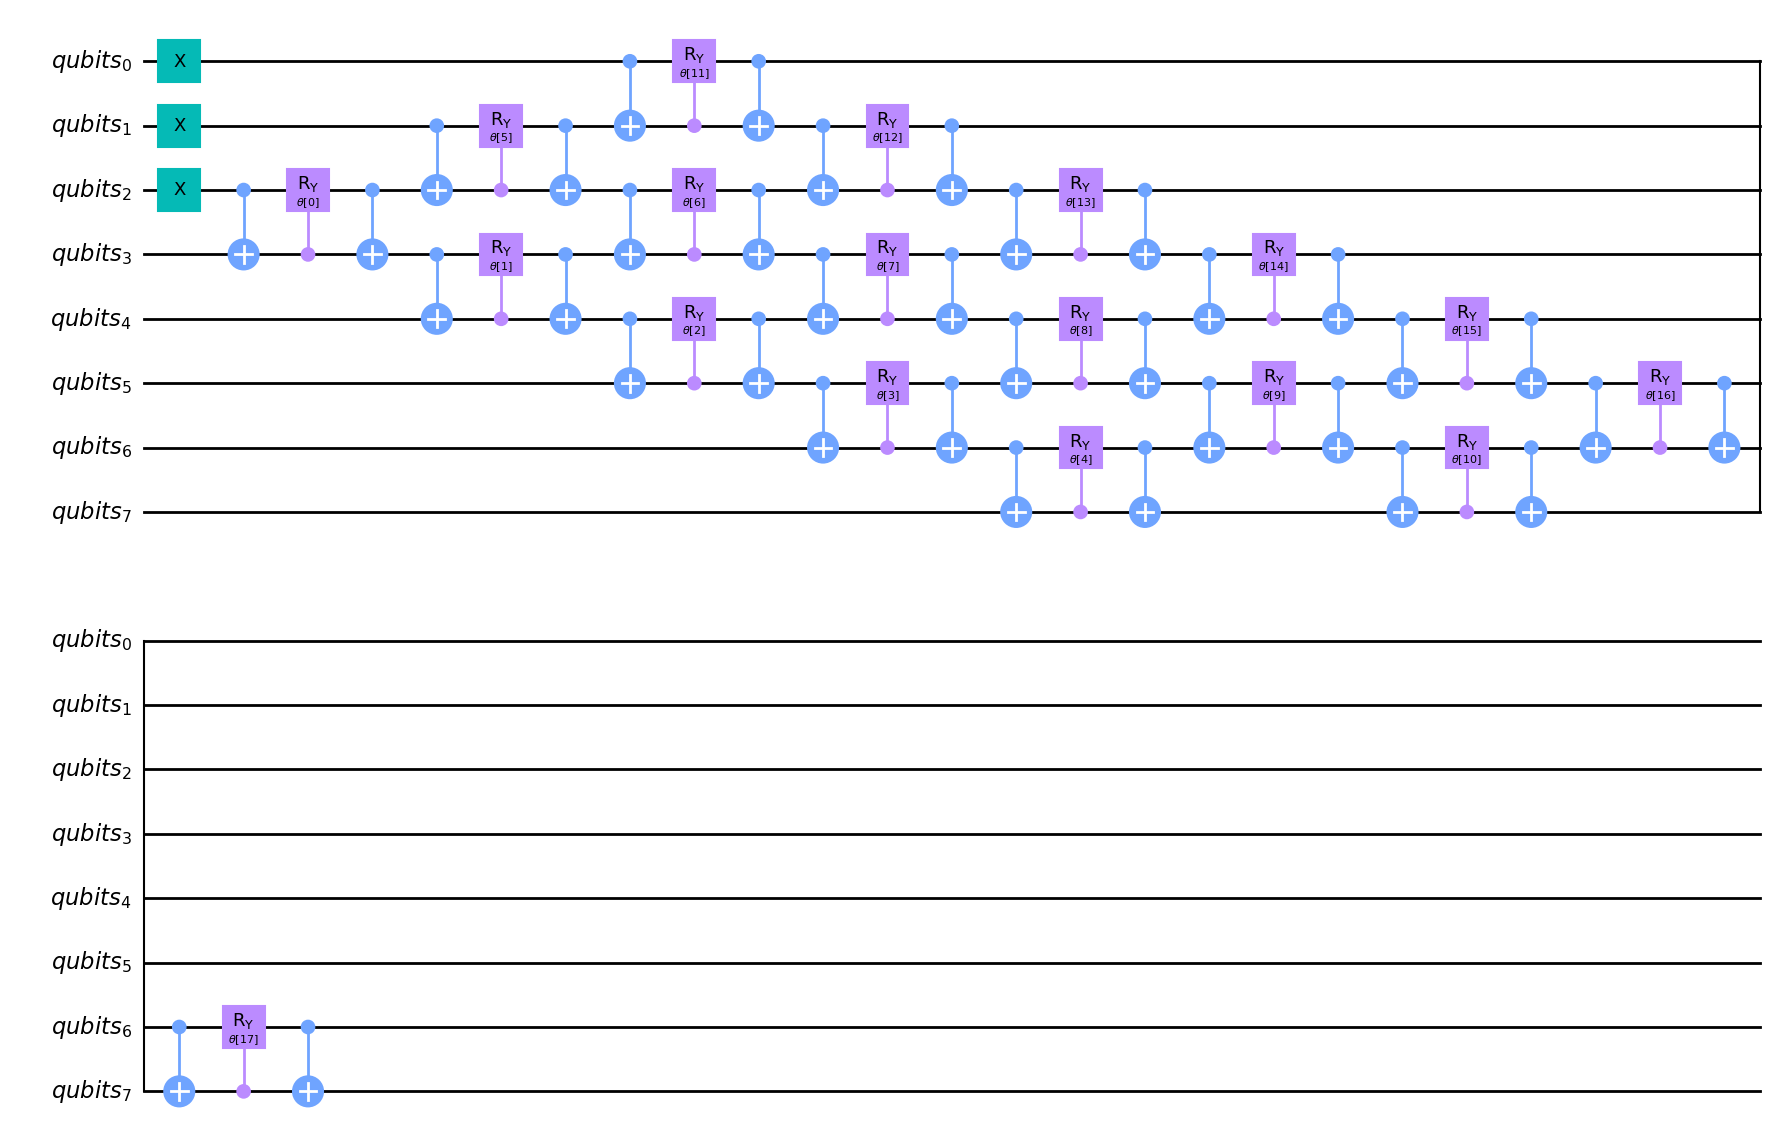

In [14]:
qc.draw(output="mpl", style="clifford")

In [15]:
def objective(x: np.ndarray) -> float:

    ansatz = qc.copy()
    params_mapper = {param: value for param, value in zip(ansatz.parameters, x)}
    ansatz = ansatz.assign_parameters(parameters=params_mapper)
    pubs = [(ansatz, ising)]
    estimator_job = estimator.run(pubs=pubs)
    estimator_result = estimator_job.result()

    obj_val = estimator_result[0].data.evs + offset

    return obj_val

In [19]:
x0 = 4*np.pi*np.random.random(size=qc.num_parameters)
result = scipy.optimize.minimize(fun=objective, x0=x0, method="cobyla")

In [20]:
result

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: -0.5186354506835765
       x: [ 1.286e+01  1.239e+01 ...  7.674e+00  5.777e+00]
    nfev: 151
   maxcv: 0.0

In [25]:
ansatz = qc.copy()
params_mapper = {param: value for param, value in zip(ansatz.parameters, result.x)}
ansatz = ansatz.assign_parameters(parameters=params_mapper)
ansatz.measure_all()

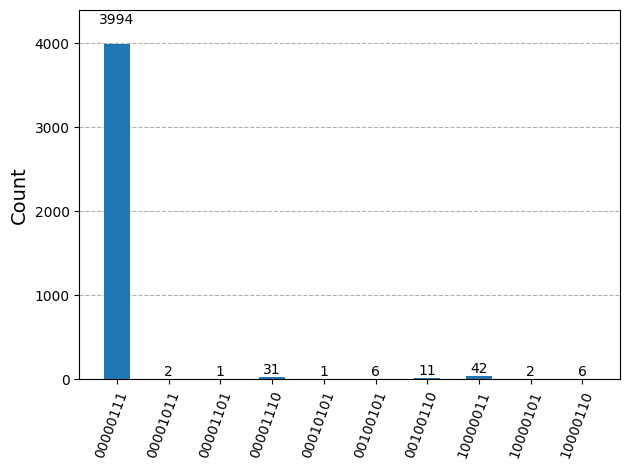

In [26]:
counts = simulator.run(circuits=ansatz, shots=4096).result().get_counts()
plot_histogram(data=counts)